# LLM  English

# Installations

In [2]:
#!pip install openai pillow numpy opencv-python jiwer

In [3]:
#!pip install torch torchvision torchaudio matplotlib pandas pillow requests jiwer

### Imports

In [4]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from jiwer import wer, cer

### Download models and Version Check

In [18]:
from openai import OpenAI

VLLM_BASE_URL = "http://127.0.0.1:8000/v1"
MODEL_NAME = "Qwen/Qwen3.5-35B-A3B-GPTQ-Int4"

client = OpenAI(
    base_url=VLLM_BASE_URL,
    api_key="EMPTY"
)

In [83]:
import sys
import torch


print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Torch CUDA:", torch.version.cuda)

Torch version: 2.11.0+cu129
CUDA available: True
GPU: NVIDIA A40
Torch CUDA: 12.9


In [20]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import requests
import pandas as pd
import re
from jiwer import wer, cer

In [21]:
prompt_text_0 = "Extract all text from this image exactly as written. Preserve line breaks."

In [60]:
prompt_text_2 = """
You are an OCR specialist.

Extract every visible character from this image exactly as it appears.

Return plain text only. Preserve the original reading order, line breaks, paragraph breaks, headings, punctuation, capitalization, spelling, abbreviations, Roman numerals, page numbers, and hyphenation exactly as printed.

Do not correct spelling or grammar.Do not put any #. Do not modernize, normalize, translate, summarize, explain, or infer missing text. Do not merge words that are split by line-ending hyphens.

If any character or word cannot be read with confidence, write [illegible] exactly at that position instead of guessing.

Do not include any comments, Markdown, labels, or additional text. Return only the transcription.
"""

In [23]:
import base64
import mimetypes


def run_ocr_one_image(image_path, prompt_text):

    mime_type, _ = mimetypes.guess_type(image_path)

    if mime_type is None:
        mime_type = "image/jpg"

    with open(image_path, "rb") as image_file:
        image_base64 = base64.b64encode(
            image_file.read()
        ).decode("utf-8")

    image_data_url = (
        f"data:{mime_type};base64,{image_base64}"
    )

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_data_url
                        }
                    },
                    {
                        "type": "text",
                        "text": prompt_text
                    }
                ]
            }
        ],
        top_p=1.0,
        temperature=0.0,
        max_tokens=2000,
        seed=42,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    output_text = response.choices[0].message.content

    if not output_text:
        raise RuntimeError(
            "Qwen returned an empty OCR response."
        )

    return output_text.strip()

### English Dataset Directory

In [24]:
ENG_IMAGES_DIR = "../images_eng"
ENG_GOLD_DIR = "../gold_english"

# Experiment 1 - Clean Baseline
Original image to OCR, Without preprocessing

In [25]:
import os

output_dir = "outputs/Experiment_1"
os.makedirs(output_dir, exist_ok=True)

### Extract text from all images

In [26]:
pages = [1,2,3,4,5,6] 

In [98]:
for p in pages:
    print("\n==============================")
    print(f"Page {p}")
    print("==============================")

    image_path = os.path.join(ENG_IMAGES_DIR,f"{p}.jpg")

    output_path = os.path.join(output_dir,f"page_{p}.txt")

    output_text = run_ocr_one_image(image_path,prompt_text_2)

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Page 1
Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics

Smart Everything

Uphill battle - Threats posed by AI to online privacy: Is there hope for
having any control over one´s online data trail, when faced by even
better AI profiling tools?

1. Introduction

Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. AI systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences, behaviour,
or interests. These profiling pra

Even though Meta has paused this specific technique, it is likely that new tracking methods will appear over time. Online privacy is harder to protect than it may seem. Privacy settings alone are often not enough to stop companies like Meta from collecting user data, as they have shown that built-in security protections on Android devices can be bypassed. One simple way to reduce tracking is to use a more privacy friendly browser [6]. Chrome allows many tracking methods, while browsers such as Firefox, Brave, DuckDuckGo, and Safari offer better protection. Android users can set these browsers as their default, and Apple users can rely on Safari, even though no browser can fully block all tracking. Using websites instead of mobile apps can also help protect privacy. Apps usually have access to more personal information, such as location, device details, and connected devices. For activities done only occasionally, like shopping or booking travel, websites are generally the safer option 

## Evaluation Experiment 1

In [99]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [100]:
results_exp1 = []

for p in pages:
    print(f"Evaluating page {p}...")

    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(output_dir, f"page_{p}.txt")

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 1...
Evaluating page 2...
Evaluating page 3...
Evaluating page 4...
Evaluating page 5...
Evaluating page 6...


In [101]:
print("=== Experiment 1 (English Dataset) - Qwen 3.5_35B_A3B ===")
df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Experiment 1 (English Dataset) - Qwen 3.5_35B_A3B ===


,page,WER,CER
0,1,0.017722,0.002774
1,2,0.027350,0.004708
2,3,0.037037,0.006046
3,4,0.011494,0.001880
4,5,0.017857,0.002728
5,6,0.013636,0.001945


In [102]:
mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

print("=== Experiment 1 (English Dataset) - Qwen 3.5_35B_A3B ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Experiment 1 (English Dataset) - Qwen 3.5_35B_A3B ===
Mean WER: 0.0208
Mean CER: 0.0033


### Save the result

In [103]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

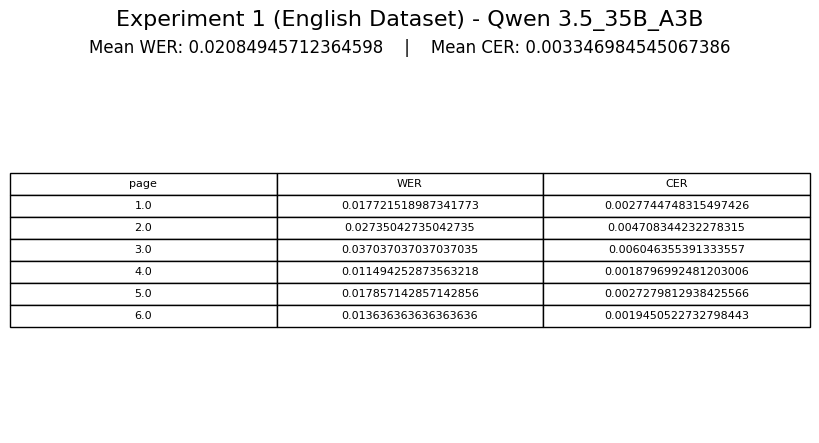

Saved: outputs/Results/experiment_1_results.png


In [104]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_1_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp1) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 1 (English Dataset) - Qwen 3.5_35B_A3B", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)


table = ax.table(
    cellText=df_exp1.values,
    colLabels=df_exp1.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

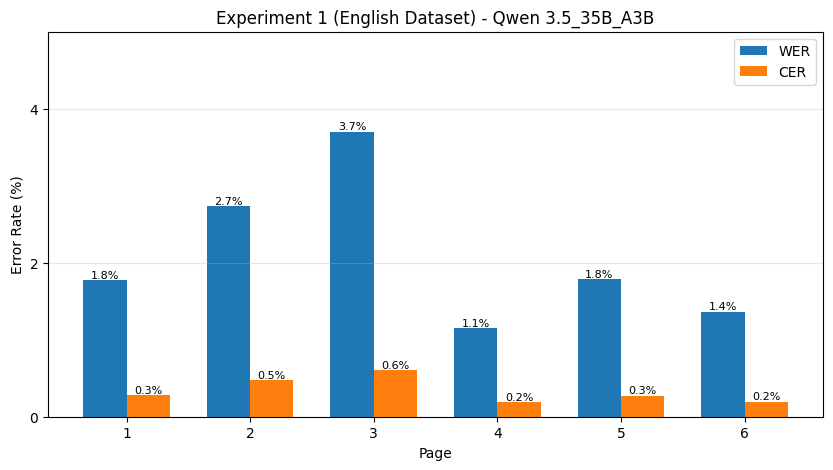

In [107]:
x = np.arange(len(df_exp1))
width = 0.35

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, wer_pct, width, label="WER")
bars2 = plt.bar(x + width/2, cer_pct, width, label="CER")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(x, df_exp1["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English Dataset) - Qwen 3.5_35B_A3B")
plt.legend()
plt.grid(axis="y", alpha=0.3)
save_path = os.path.join(output_dir_result_1,"experiment_1_graph_results.png")
plt.savefig(save_path,dpi=300,bbox_inches="tight")
plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 2))
plt.show()

#### 4. Word Detection Rate

Word Detection Rate compares the number of words in the gold-standard text with the number of words produced by PyTesseract. The word detection rate shows whether the OCR system extracted too few, too many, or approximately the correct number of words.

A value close to 100% means that the OCR output contains a similar number of words as the gold standard. A value below 100% suggests that some words may have been missed, while a value above 100% may indicate extra or incorrectly split words.

In [70]:
word_detection_results = []

for p in pages:
    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")
    pred_path = os.path.join(output_dir, f"page_{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    gold_words = len(gold_norm.split())
    ocr_words = len(pred_norm.split())

    detection_rate = (ocr_words / gold_words) * 100 if gold_words > 0 else 0

    page_wer = df_exp1.loc[
        df_exp1["page"] == p,
        "WER"
    ].values[0]

    word_detection_results.append({
        "page": p,
        "Gold Words": gold_words,
        "OCR Words": ocr_words,
        "WER": page_wer,
        "Word Detection Rate (%)": detection_rate
    })

word_detection_df = pd.DataFrame(word_detection_results)

word_detection_df

,page,Gold Words,OCR Words,WER,Word Detection Rate (%)
0,1,395,394,0.017722,99.746835
1,2,585,585,0.027350,100.000000
2,3,459,459,0.037037,100.000000
3,4,435,435,0.011494,100.000000
4,5,392,392,0.017857,100.000000
5,6,660,659,0.013636,99.848485


##### Observations(Word Detection Rate)
Page 6 achieved a Word Detection Rate of 99.85%, indicating that almost all words were successfully detected by Tesseract. However, the WER of 10.6% shows that some detected words were recognized incorrectly. This demonstrates that a high detection rate does not necessarily imply perfect recognition accuracy, as OCR may locate words correctly while still producing transcription errors.

#### 5. OCR Speed Analysis

We will measure how long GPT takes to process each page in Experiment 1. Runtime is calculated separately for every image, and then the average and total processing time are reported.This helps evaluate not only OCR accuracy, but also processing efficiency.

In [71]:
import time

ocr_speed_results = []

for p in pages:

    image_path = os.path.join(
        ENG_IMAGES_DIR,
        f"{p}.jpg"
    )

    start_time = time.time()

    output_text = run_ocr_one_image(
        image_path,
        prompt_text_0
    )

    end_time = time.time()

    elapsed_time = end_time - start_time

    ocr_speed_results.append({
        "page": p,
        "OCR Time (seconds)": elapsed_time
    })

ocr_speed_df = pd.DataFrame(ocr_speed_results)

ocr_speed_df

,page,OCR Time (seconds)
0,1,5.868882
1,2,8.519256
2,3,7.131817
3,4,6.432123
4,5,6.172609
5,6,9.003575


In [72]:
average_time = ocr_speed_df["OCR Time (seconds)"].mean()
total_time = ocr_speed_df["OCR Time (seconds)"].sum()

print(f"Average OCR time per page: {average_time:.3f} seconds")
print(f"Total OCR time for Experiment 1: {total_time:.3f} seconds")

Average OCR time per page: 7.188 seconds
Total OCR time for Experiment 1: 43.128 seconds


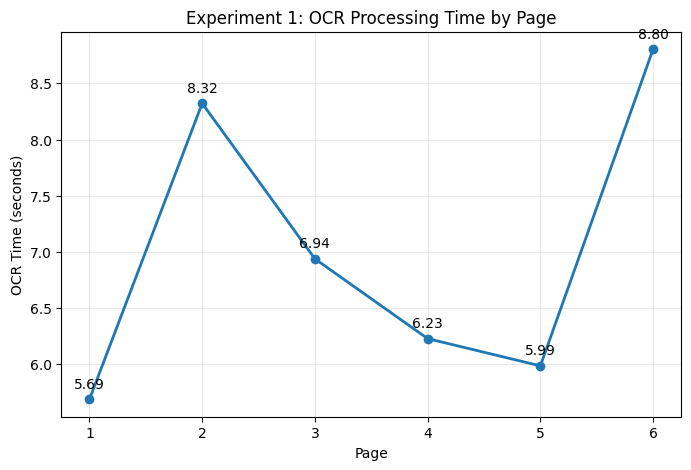

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    ocr_speed_df["page"],
    ocr_speed_df["OCR Time (seconds)"],
    marker="o",
    linewidth=2
)

for _, row in ocr_speed_df.iterrows():
    plt.annotate(
        f'{row["OCR Time (seconds)"]:.2f}',
        (
            row["page"],
            row["OCR Time (seconds)"]
        ),
        xytext=(0,8),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Page")
plt.ylabel("OCR Time (seconds)")
plt.title("Experiment 1: OCR Processing Time by Page")

plt.xticks(ocr_speed_df["page"])
plt.grid(True, alpha=0.3)

plt.show()

In [53]:
speed_analysis_df = (
    word_detection_df[
        ["page", "WER", "Word Detection Rate (%)"]
    ]
    .merge(
        ocr_speed_df,
        on="page"
    )
)

speed_analysis_df

,page,WER,Word Detection Rate (%),OCR Time (seconds)
0,1,0.022785,100.253165,5.689800
1,2,0.027350,100.000000,8.322237
2,3,0.006536,100.653595,6.938824
3,4,0.013793,100.229885,6.229012
4,5,0.022959,100.000000,5.986553
5,6,0.013636,99.848485,8.803917


##### Observation(OCR Speed Analysis)
A tendency can be observed where pages with lower word detection rates were processed faster by Tesseract. For example, Page 4 had the lowest detection rate (57.7%) and the shortest OCR time (1.08 s), while pages with nearly complete word detection required slightly more processing time.

At the same time, Variations in runtime may be influenced by factors such as page complexity, text density, image dimensions, and font characteristics. Pages with higher text density may require slightly longer processing times.

#### 6. Page-Level Performance Ranking

Pages can be ranked according to their OCR performance using Word Error Rate (WER). Lower WER values indicate better OCR quality, while higher WER values indicate greater recognition errors. This ranking helps identify which pages were easiest and most difficult for Tesseract to process.

In [54]:
ranking_df = df_exp1.sort_values(
    by="WER",
    ascending=True
).reset_index(drop=True)

ranking_df["Rank"] = ranking_df.index + 1

ranking_df = ranking_df[
    ["Rank", "page", "WER", "CER"]
]

ranking_df

,Rank,page,WER,CER
0,1,3,0.006536,0.004367
1,2,6,0.013636,0.001945
2,3,4,0.013793,0.003383
3,4,1,0.022785,0.004756
4,5,5,0.022959,0.004677
5,6,2,0.027350,0.004708


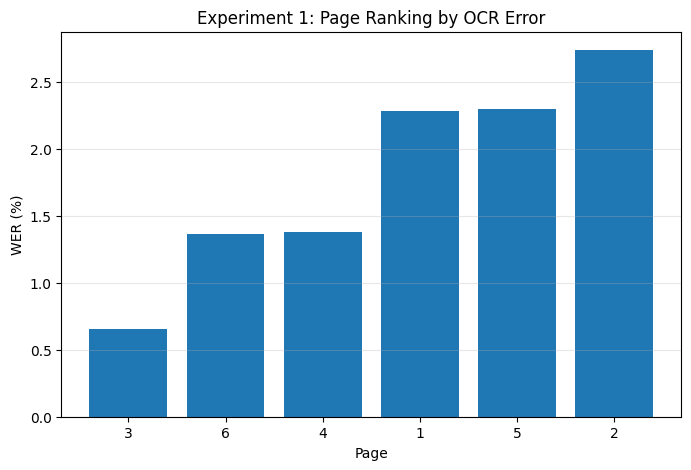

In [57]:
plt.figure(figsize=(8,5))

plt.bar(
    ranking_df["page"].astype(str),
    ranking_df["WER"] * 100
)

plt.xlabel("Page")
plt.ylabel("WER (%)")
plt.title("Experiment 1: Page Ranking by OCR Error")

plt.grid(axis="y", alpha=0.3)

plt.show()